In [18]:
.libPaths('/home/lixinxing/anaconda3/envs/my_monocle3_2/lib/R/library')

In [20]:
options(stringsAsFactors = FALSE)
library(Seurat)
library(tidyverse)
library(viridis)
library(RColorBrewer)
library(cytosignal)

In [23]:
seurat<-readRDS('/home/lixinxing/IBD/data_sp/ibd_bin50_tissue_5_sub_anno_3_2.rds')
seurat 

An object of class Seurat 
16405 features across 118654 samples within 1 assay 
Active assay: RNA (16405 features, 0 variable features)
 7 dimensional reductions calculated: means_cell_abundance_w_sf, pca, q05_cell_abundance_w_sf, q95_cell_abundance_w_sf, spatial, stds_cell_abundance_w_sf, umap

In [24]:
unique(seurat$sample)

[1] "C02940C113" "B03502C3"   "B03501E1"   "A03177A611" "B03501C6"  
 [6] "B03501C5"   "B01317F4"   "B03501C4"   "B03502E2"   "B03501E2"  
[11] "B03501A5"   "B03501C3"

In [25]:
results <- list()

for (sample_id in unique(seurat$sample)) {

    seurat_subset <- subset(x = seurat, subset = sample == sample_id)
    
    data.input = Seurat::GetAssayData(seurat_subset, slot = "data", assay = "RNA") 
    meta = seurat_subset@meta.data
    meta=data.frame(meta[,c('tissue')],row.names = rownames(meta))
    colnames(meta)=c('tissue')

    cluster=factor(meta$tissue)
    names(cluster)<-colnames(data.input)

    imagerow <- seurat_subset@meta.data$imagerow
    imagecol <- seurat_subset@meta.data$imagecol
    spatial.locs <- data.frame(imagerow, imagecol, row.names = rownames(seurat_subset@meta.data))
    colnames(spatial.locs)=c('x','y')

    scale.factors = list(spot.diameter = 25, spot = 50) 
    spot.size=25
    ratio=conversion.factor=scale.factors$spot.diameter/scale.factors$spot
    tol=25/2
    spatial.factors = data.frame(ratio = conversion.factor, tol = spot.size/2)

    cs <- createCytoSignal(raw.data = data.input, cells.loc = as.matrix(spatial.locs), clusters = cluster)
    cs <- addIntrDB(cs, g_to_u, db.diff, db.cont, inter.index)
    cs <- removeLowQuality(cs, counts.thresh = 300)
    cs <- changeUniprot(cs)
    cs <- inferEpsParams(cs, scale.factor = 0.5)
    cs <- findNN(cs)
    cs <- imputeLR(cs)

    cs <- inferIntrScore(cs)
    cs <- inferSignif(cs, p.value = 0.5, reads.thresh = 50, sig.thresh = 50)
    cs <- rankIntrSpatialVar(cs)
    
    # plotEdge(cs, 'CPI-CS04CBDE052', pt.size = 0.15,slot.use = "GauEps-Raw", signif.use = "result",pt.sig.size = 1)
    results[[sample_id]] <- cs
    print(paste("Added cs for sample", sample_id))
    # saveRDS(cs, file = paste0("cytosignal_", sample_id, ".rds"))
}

Number of genes in the database: 803

Number of low-quality intr genes: 386

Cell count threshold: 300

No cells removed

Gene count threshold: 50

Removed 5454/16405 low quality genes.

Number of genes in the database: 803

Finding neighbors in epsilon circle with tag: GauEps...

Determining self weight automatically...

Finding neighbors using DT with tag: DT...

Setting ImpData obj using NO imputation...

DT has been done before, taking the same neighbors.

Imputing using GauEps...

Imputing using DT...

== Calculating diffusible ligand-receptor scores ==

Computing LR-scores using diff_dep database.

- Ligand: GauEps, Receptor: Raw.

- Number of valid intrs: 523 out of 754 from database.

Permuting whole dataset 50 times...

- Permuting ligand Imp slot: GauEps...



- Permuting receptor Imp slot: Raw...



- Calculating NULL scores...

Permuting scores on Score slot: GauEps-Raw...

- A total of 72 interactions are empty in NULL scores.

- Removing 72 corresponding intr from REAL scores.

== Calculating contact-dependent ligand-receptor scores ==

Computing LR-scores using cont_dep database.

- Ligand: DT, Receptor: Raw.

- Number of valid intrs: 88 out of 109 from database.

Permuting whole dataset 50 times...

- Permuting ligand Imp slot: DT...



- Permuting receptor Imp slot: Raw...



- Calculating NULL scores...

Permuting scores on Score slot: DT-Raw...

Computing LR-scores using cont_dep database.

- Ligand: Raw, Receptor: Raw.

- Number of valid intrs: 88 out of 109 from database.

Permuting whole dataset 50 times...

- Permuting ligand Imp slot: Raw...



...

## ===== SPARK-X INPUT INFORMATION ==== 
## number of total samples: 13021 
## number of total genes: 88 
## Running with single core, may take some time 
## Testing With Projection Kernel
## Testing With Gaussian Kernel 1
## Testing With Gaussian Kernel 2
## Testing With Gaussian Kernel 3
## Testing With Gaussian Kernel 4
## Testing With Gaussian Kernel 5
## Testing With Cosine Kernel 1
## Testing With Cosine Kernel 2
## Testing With Cosine Kernel 3
## Testing With Cosine Kernel 4
## Testing With Cosine Kernel 5


- Number of spatially variable interactions: 71 out of 71 high-quality interactions.

Ranking high-quality interactions by spatial variability using LR score at Raw-Raw... 



## ===== SPARK-X INPUT INFORMATION ==== 
## number of total samples: 12477 
## number of total genes: 88 
## Running with single core, may take some time 
## Testing With Projection Kernel
## Testing With Gaussian Kernel 1
## Testing With Gaussian Kernel 2
## Testing With Gaussian Kernel 3
## Testing With Gaussian Kernel 4
## Testing With Gaussian Kernel 5
## Testing With Cosine Kernel 1
## Testing With Cosine Kernel 2
## Testing With Cosine Kernel 3
## Testing With Cosine Kernel 4
## Testing With Cosine Kernel 5


- Number of spatially variable interactions: 45 out of 45 high-quality interactions.



[1] "Added cs for sample B03501C3"


In [90]:
options(repr.plot.width=6,repr.plot.height=6)

Now plotting edges for interaction: IL10-IL10 receptor ...

Now plotting edges for interaction: IL10-IL10 receptor ...



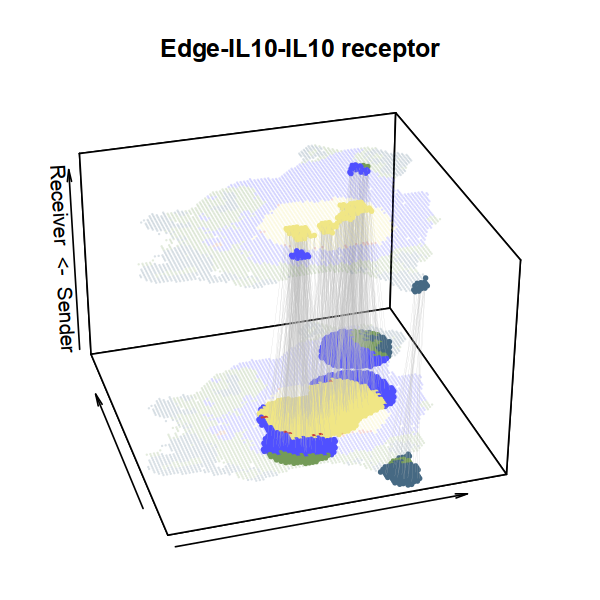

Now plotting edges for interaction: IL10-IL10 receptor ...



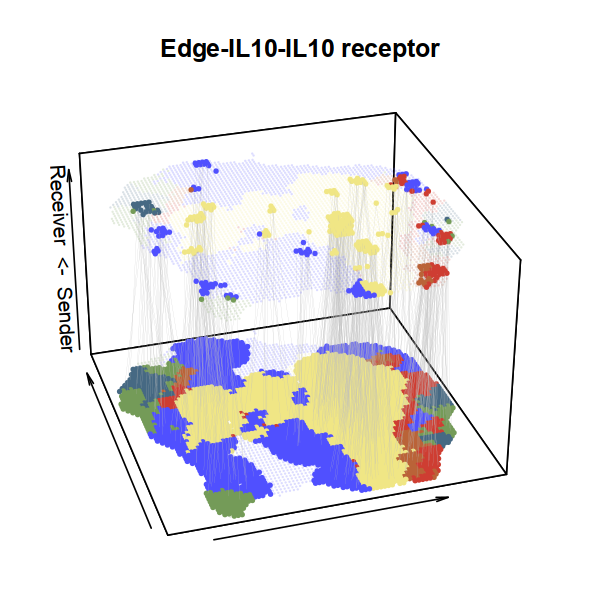

Now plotting edges for interaction: IL10-IL10 receptor ...



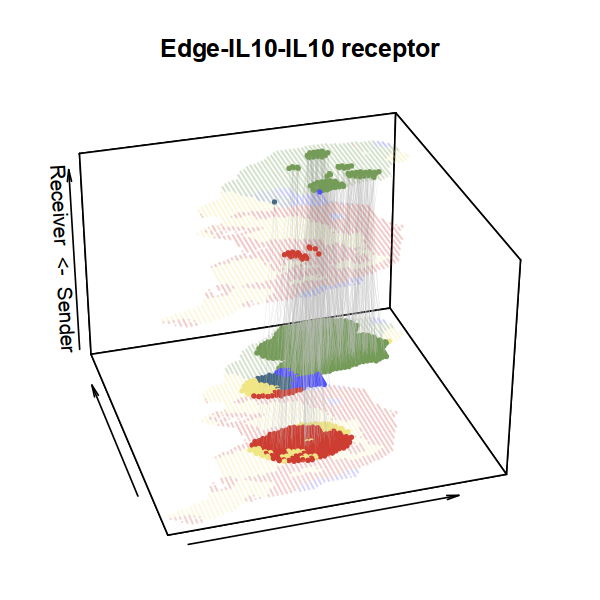

Now plotting edges for interaction: IL10-IL10 receptor ...



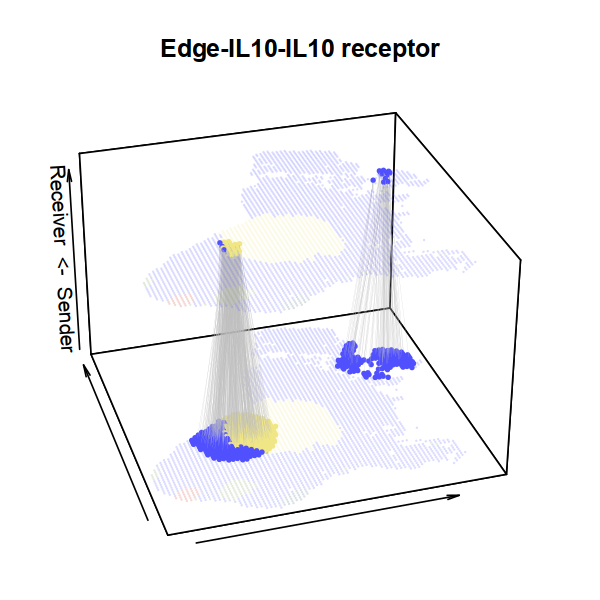

Now plotting edges for interaction: IL10-IL10 receptor ...



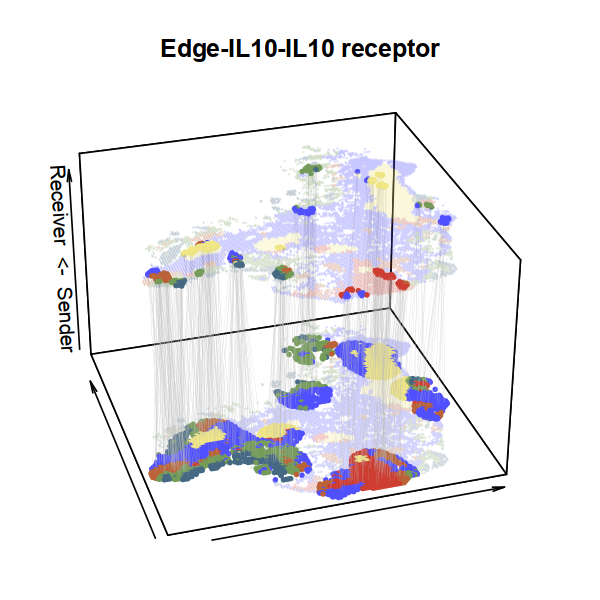

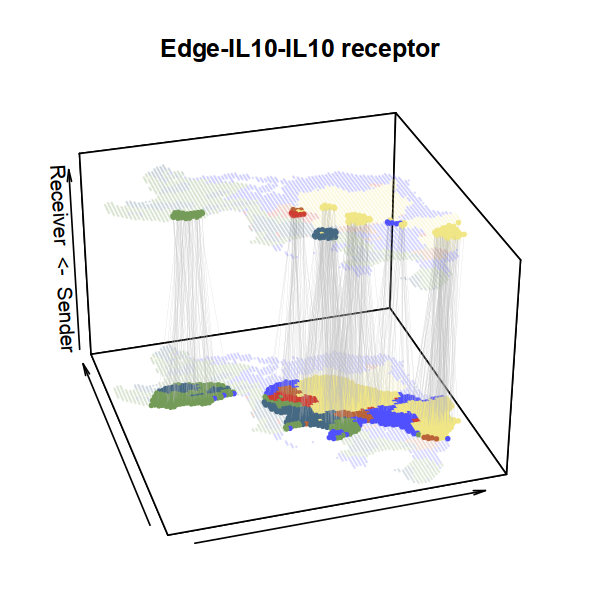

In [140]:
sample_list <- unique(seurat$sample)
sample_list<-c('B03501E1','B03501E2','B03501C6','B03501C3','B01317F4','B03501C5')

for (sample in sample_list) {
    print(plotEdge(results[[sample]], 'CPI-CS04CBDE052', 
             pt.size = 0.15, 
            type='receiver',
             slot.use = "GauEps-Raw", 
             signif.use = "result", 
             pt.sig.size = 0.5))
}


Now plotting edges for interaction: IL10-IL10 receptor ...



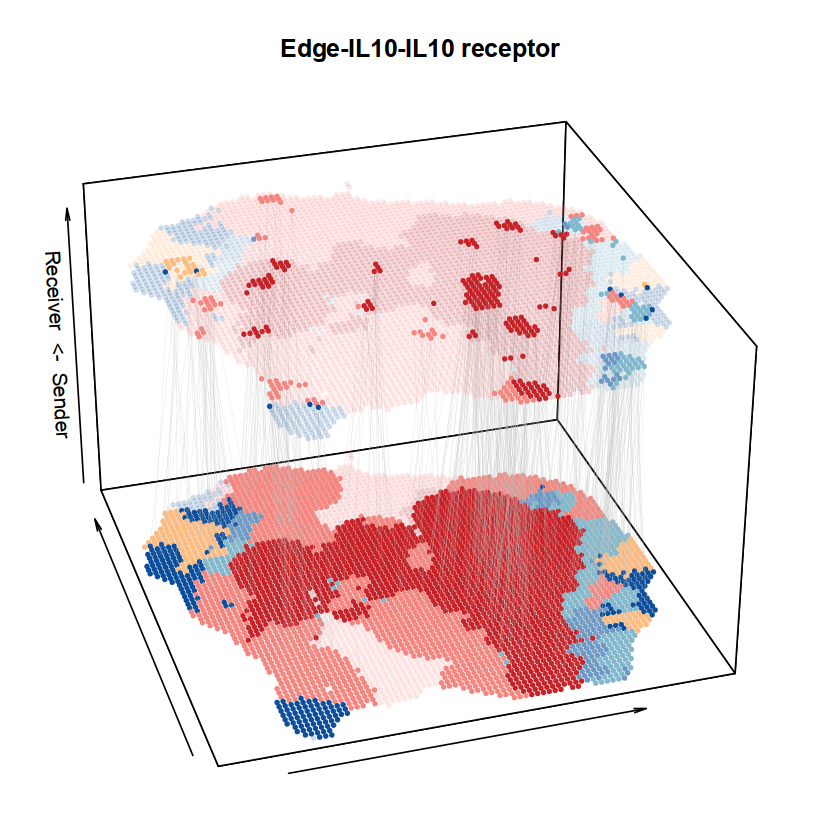

In [206]:
options(repr.plot.width=7,repr.plot.height=7)
plotEdge(results[['B03501E2']], 'CPI-CS04CBDE052', pt.size =0.5,slot.use = "GauEps-Raw", signif.use = "result",colors.list=c("#F5867F","#81b8cd","#0C4E9B","#C72228","#FFBC80","#6B98C4"),pt.sig.size = 0.5,line.width = 0.02)

Now plotting edges for interaction: IL10-IL10 receptor ...



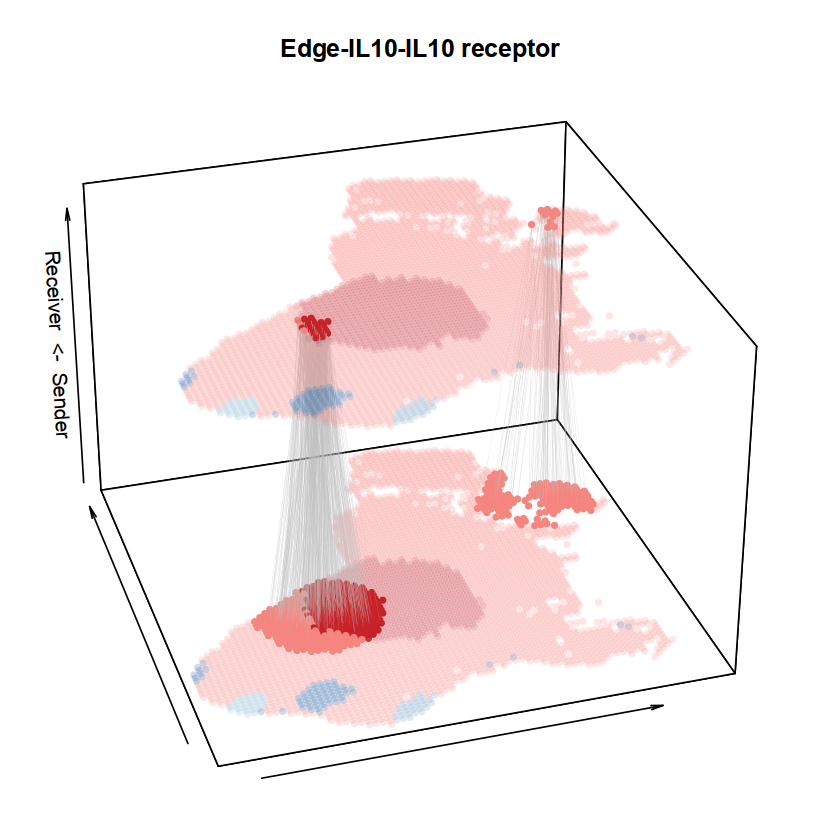

In [225]:
plotEdge(results[['B03501C3']], 
         'CPI-CS04CBDE052', 
         pt.size = 0.7,
         slot.use = "GauEps-Raw", 
         signif.use = "result", 
         colors.list = c("#F5867F", "#81b8cd", "#0c4e9b", "#C72228", "#6B98C4"),
         pt.sig.size = 0.7,
         line.width=0.02,
         return.plot = TRUE)